# QAOA — Quantum Approximate Optimization Algorithm


**Instructor notebook** — built with [Qiskit](https://qiskit.org)

---

## Learning Objectives
By the end of this notebook, students will be able to:
1. Explain why combinatorial optimization is hard classically and why QAOA is a natural
   NISQ-era candidate algorithm for it.
2. Formulate a combinatorial optimization problem (**Max-Cut**) as an **Ising / QUBO** cost
   Hamiltonian.
3. Explain the two alternating unitaries of QAOA — the **Cost unitary** $U_C(\gamma)$ and the
   **Mixer unitary** $U_M(\beta)$ — and their connection to the **Quantum Adiabatic Theorem**.
4. Build a QAOA circuit in Qiskit from scratch (no black-box library call) for arbitrary depth $p$.
5. Visualize the **optimization landscape** of the QAOA cost function over $(\gamma, \beta)$.
6. Use a classical optimizer to train QAOA parameters, and track convergence.
7. Evaluate solution quality using the **approximation ratio**, and see how it improves with
   circuit depth $p$.
8. Understand how the same QUBO framework extends to other problems (Knapsack, TSP, etc.).

---

## Table of Contents
1. [Motivation: Combinatorial Optimization on NISQ Devices](#1)
2. [From Classical to Quantum: Ising Models, QUBO, and the Adiabatic Connection](#2)
3. [Setup](#3)
4. [The Problem: Max-Cut on a Graph](#4)
5. [The Cost Hamiltonian](#5)
6. [The QAOA Ansatz — Cost Unitary and Mixer Unitary](#6)
7. [Assembling the Full QAOA Circuit ($p=1$)](#7)
8. [Evaluating the Cost Function](#8)
9. [Visualizing the Optimization Landscape](#9)
10. [Classical Parameter Optimization](#10)
11. [Sampling the Optimized Circuit](#11)
12. [Going Deeper: Increasing $p$](#12)
13. [Approximation Ratio vs. Depth](#13)
14. [Beyond Max-Cut: QUBO for Other Problems](#14)
15. [Summary & Exercises for Students](#15)


<a id="1"></a>
## 1. Motivation: Combinatorial Optimization on NISQ Devices

Many real-world problems boil down to: **"out of an exponential number of possible
configurations, find the one that minimizes (or maximizes) some cost function."** Examples:

- **Max-Cut** — partition a graph's nodes into two sets to maximize the number of edges crossing
  the partition (used in circuit design, clustering, physics).
- **Knapsack** — choose items to maximize value under a weight constraint.
- **Traveling Salesperson (TSP)** — find the shortest route visiting every city once.
- **Portfolio optimization**, **scheduling**, **graph coloring**, and many more.

These are typically **NP-hard**: no known classical algorithm solves every instance quickly.
Quantum computers offer a possible path via the **Quantum Approximate Optimization Algorithm
(QAOA)**, proposed by Farhi, Goldstone & Gutmann (2014). Unlike Grover's algorithm (exact
oracle-based search), QAOA is a **variational, hybrid quantum-classical algorithm**:

```
 ┌─────────────────────┐        ┌───────────────────────┐
 │   Quantum Computer   │  ───▶  │  Classical Optimizer   │
 │ prepares state,      │        │  updates parameters    │
 │ measures cost         │  ◀───  │  (γ, β) to reduce cost │
 └─────────────────────┘        └───────────────────────┘
```

This makes QAOA well suited to today's noisy, limited-qubit-count ("NISQ") hardware, since the
quantum circuit is shallow and the heavy lifting of parameter search is partly offloaded to a
classical computer.


<a id="2"></a>
## 2. From Classical to Quantum: Ising Models, QUBO, and the Adiabatic Connection

### QUBO → Ising
Combinatorial problems are commonly written as a **Quadratic Unconstrained Binary Optimization
(QUBO)** problem: find $x \in \{0,1\}^n$ minimizing

$$ C(x) = \sum_i a_i x_i + \sum_{i<j} b_{ij}\, x_i x_j $$

Substituting $x_i = \frac{1-z_i}{2}$ with $z_i \in \{-1, +1\}$ converts this into an **Ising
model** cost function, which maps directly onto Pauli-$Z$ operators acting on qubits:

$$ H_C = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j $$

The **ground state** of $H_C$ (the qubit configuration with lowest energy) is exactly the optimal
solution to the original combinatorial problem.

### The Adiabatic Connection
The **Quantum Adiabatic Theorem** says: if you start in the ground state of an easy-to-prepare
Hamiltonian $H_M$ (the "mixer") and slowly evolve to the hard Hamiltonian $H_C$, the system stays
in the instantaneous ground state — ending in the solution we want.

QAOA is a **Trotterized, finite-depth approximation** of this adiabatic path: instead of a slow
continuous evolution, it alternates $p$ times between short pulses of $H_C$ and $H_M$:

$$ |\gamma, \beta\rangle = e^{-i\beta_p H_M} e^{-i\gamma_p H_C} \cdots e^{-i\beta_1 H_M} e^{-i\gamma_1 H_C} |s\rangle $$

where $|s\rangle = |+\rangle^{\otimes n}$ (equal superposition) is the ground state of the
mixer $H_M = \sum_i X_i$. As $p \to \infty$, QAOA approaches the exact adiabatic result; even
small $p$ (1, 2, 3 layers) often gives useful approximate solutions.


<a id="3"></a>
## 3. Setup


In [1]:
# ============================================================
#  IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

import qiskit
print("Qiskit version:", qiskit.__version__)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Palette used throughout the notebook
NAVY   = '#1E4080'
GOLD   = '#C8973A'
INK    = '#1A2744'
RED    = '#8B0000'


Qiskit version: 2.5.0


<a id="4"></a>
## 4. The Problem: Max-Cut on a Graph

**Max-Cut definition:** given a graph $G=(V,E)$, split $V$ into two sets $S$ and $\bar S$ to
maximize the number of edges with one endpoint in each set.

We'll use a small 5-node graph — a 5-cycle plus one diagonal edge — small enough to simulate
exactly and to brute-force check by hand, but non-trivial enough to be interesting (it is **not**
simply bipartite).


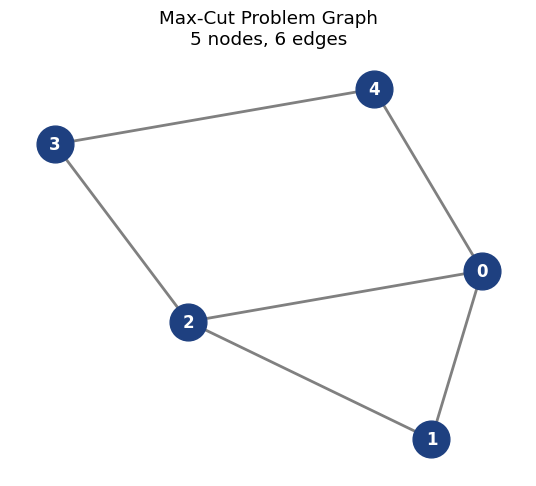

Edges: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2)]


In [2]:
# ============================================================
#  DEFINE THE GRAPH
# ============================================================
n_nodes = 5
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2)]

G = nx.Graph()
G.add_nodes_from(range(n_nodes))
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(5.5, 5))
nx.draw_networkx_nodes(G, pos, node_color=NAVY, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', ax=ax)
ax.set_title(f"Max-Cut Problem Graph\n{n_nodes} nodes, {len(edges)} edges")
ax.axis('off')
plt.tight_layout()
plt.show()

print("Edges:", edges)


<a id="5"></a>
## 5. The Cost Hamiltonian

For Max-Cut, a classical bitstring $x \in \{0,1\}^n$ assigns each node to set $S$ ($x_i{=}1$) or
$\bar S$ ($x_i{=}0$). The number of cut edges is:

$$ C(x) = \sum_{(i,j)\in E} \big(x_i + x_j - 2 x_i x_j\big) = \sum_{(i,j)\in E} \frac{1 - z_i z_j}{2} $$

using $z_i = 1-2x_i \in \{-1,+1\}$. This maps to the cost Hamiltonian:

$$ H_C = \sum_{(i,j)\in E} \frac{1}{2}\big(I - Z_i Z_j\big) $$

**Maximizing $C(x)$ = minimizing $-H_C$.** In the code below we define the classical cost
function directly on bitstrings (useful for brute-force verification), and separately build the
quantum circuit that implements $e^{-i\gamma H_C}$.


In [3]:
def maxcut_cost(bitstring: str, edge_list=edges) -> int:
    '''Classical Max-Cut cost: number of edges cut by this bitstring partition.'''
    x = [int(b) for b in bitstring]
    return sum(x[i] != x[j] for i, j in edge_list)


# Brute-force: check every possible partition (2^5 = 32 -- trivial for a classical computer,
# but this number explodes exponentially for larger graphs, which is exactly why we need
# better-than-brute-force approaches for large instances!)
best_cost = -1
best_bitstrings = []
all_costs = {}
for bits in product('01', repeat=n_nodes):
    bstr = ''.join(bits)
    c = maxcut_cost(bstr)
    all_costs[bstr] = c
    if c > best_cost:
        best_cost = c
        best_bitstrings = [bstr]
    elif c == best_cost:
        best_bitstrings.append(bstr)

print(f"Brute-force optimum: cost = {best_cost}")
print(f"Optimal bitstring(s): {best_bitstrings}")


Brute-force optimum: cost = 5
Optimal bitstring(s): ['00101', '01101', '10010', '11010']


<a id="6"></a>
## 6. The QAOA Ansatz — Cost Unitary and Mixer Unitary

### Cost unitary $U_C(\gamma) = e^{-i\gamma H_C}$
Since $H_C$ is a sum of commuting $Z_iZ_j$ terms (up to the constant/identity part), this
unitary decomposes into one **RZZ gate per edge**:

$$ e^{-i\gamma H_C} = \prod_{(i,j)\in E} e^{-i\gamma \frac{1}{2}(I - Z_iZ_j)} \;\propto\; \prod_{(i,j)\in E} \text{RZZ}(\gamma)_{ij} $$

(the identity term only contributes an irrelevant global phase.)

### Mixer unitary $U_M(\beta) = e^{-i\beta H_M}$, with $H_M = \sum_i X_i$
This is simply an **RX rotation on every qubit**:

$$ e^{-i\beta H_M} = \prod_i \text{RX}(2\beta)_i $$

The mixer's job is to move amplitude *between* computational basis states — without it, the
cost unitary alone (which is diagonal) could never change measurement probabilities at all.


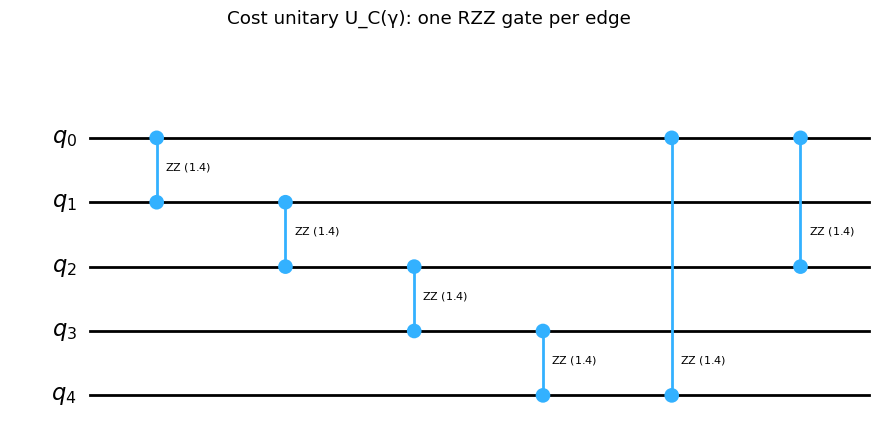

In [4]:
def cost_layer(qc: QuantumCircuit, gamma: float, edge_list=edges):
    '''Apply e^{-i*gamma*H_C}: one RZZ gate per graph edge.'''
    for i, j in edge_list:
        qc.rzz(2 * gamma, i, j)
    return qc


def mixer_layer(qc: QuantumCircuit, beta: float):
    '''Apply e^{-i*beta*H_M}: one RX rotation per qubit.'''
    qc.rx(2 * beta, range(qc.num_qubits))
    return qc


# Visualize a single cost layer and a single mixer layer in isolation
demo_cost = QuantumCircuit(n_nodes, name="Cost layer")
cost_layer(demo_cost, gamma=0.7)
fig = demo_cost.draw(output='mpl', style={'name': 'iqp'}, fold=-1)
fig.suptitle("Cost unitary U_C(γ): one RZZ gate per edge", y=1.05)
fig


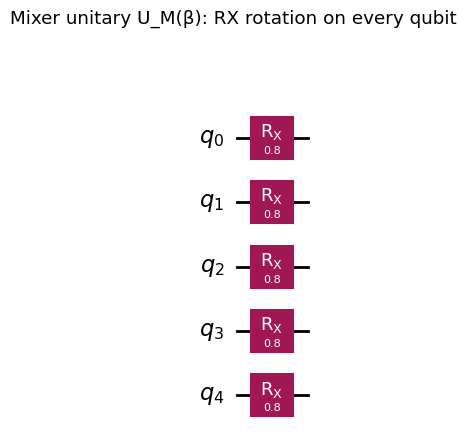

In [5]:
demo_mixer = QuantumCircuit(n_nodes, name="Mixer layer")
mixer_layer(demo_mixer, beta=0.4)
fig = demo_mixer.draw(output='mpl', style={'name': 'iqp'}, fold=-1)
fig.suptitle("Mixer unitary U_M(β): RX rotation on every qubit", y=1.05)
fig


<a id="7"></a>
## 7. Assembling the Full QAOA Circuit ($p=1$)

**Recipe:**
1. Initialize all qubits in $|+\rangle^{\otimes n}$ (ground state of the mixer) using Hadamards.
2. Apply $p$ alternating rounds of (Cost layer with $\gamma_k$) → (Mixer layer with $\beta_k$).
3. Measure all qubits.

For now we use $p=1$, i.e. one $\gamma$ and one $\beta$ parameter.


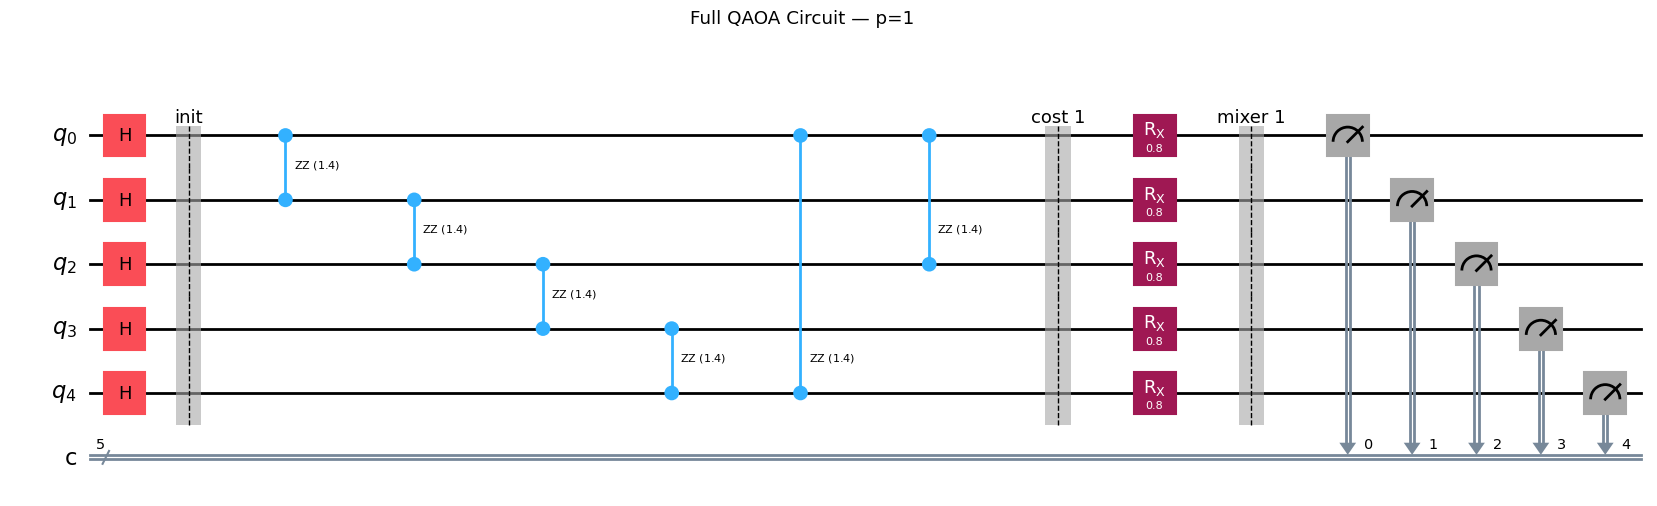

In [6]:
def qaoa_circuit(n_qubits: int, gammas, betas, edge_list=edges, measure=True) -> QuantumCircuit:
    '''
    Build a full QAOA circuit for Max-Cut.
    gammas, betas: lists of length p (circuit depth)
    '''
    assert len(gammas) == len(betas)
    qc = QuantumCircuit(n_qubits, n_qubits)

    # Step 1: initial superposition |+>^n
    qc.h(range(n_qubits))
    qc.barrier(label="init")

    # Step 2: p alternating layers
    for k, (g, b) in enumerate(zip(gammas, betas)):
        cost_layer(qc, g, edge_list)
        qc.barrier(label=f"cost {k+1}")
        mixer_layer(qc, b)
        qc.barrier(label=f"mixer {k+1}")

    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc


# Example circuit at an arbitrary (gamma, beta) just to look at the structure
qaoa_p1_demo = qaoa_circuit(n_nodes, gammas=[0.7], betas=[0.4])
fig = qaoa_p1_demo.draw(output='mpl', style={'name': 'iqp'}, fold=-1)
fig.suptitle("Full QAOA Circuit — p=1", y=1.02)
fig


<a id="8"></a>
## 8. Evaluating the Cost Function

To evaluate how good a set of parameters $(\gamma,\beta)$ is, we need the **expected Max-Cut
value** under the resulting quantum state:

$$ \langle C \rangle (\gamma,\beta) = \sum_{x} P(x \mid \gamma,\beta)\, C(x) $$

We compute this by running the circuit and averaging the classical cost function over the
measured bitstrings (weighted by how often each occurred).


In [7]:
simulator = AerSimulator()

def expected_cost(gammas, betas, shots=4096, edge_list=edges):
    '''Run the QAOA circuit and return the shots-weighted average Max-Cut cost.'''
    qc = qaoa_circuit(n_nodes, gammas, betas, edge_list)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()

    total_cost = 0
    total_shots = 0
    for bitstring, freq in counts.items():
        # Qiskit returns bitstrings with qubit 0 as the RIGHTMOST character
        cost = maxcut_cost(bitstring[::-1], edge_list)
        total_cost += cost * freq
        total_shots += freq
    return total_cost / total_shots


# Sanity check at one arbitrary parameter point
test_val = expected_cost([0.7], [0.4])
print(f"Expected cut value at (γ=0.7, β=0.4): {test_val:.3f}  "
      f"(brute-force optimum = {best_cost})")


Expected cut value at (γ=0.7, β=0.4): 2.639  (brute-force optimum = 5)


<a id="9"></a>
## 9. Visualizing the Optimization Landscape

Before handing parameter tuning to a classical optimizer, let's **look at the landscape** of
$\langle C \rangle(\gamma, \beta)$ for $p=1$. This builds crucial intuition: the classical
optimizer is just a hill-climber on this surface.

We evaluate it **exactly** (via the statevector, no shot noise) on a grid so the plot is smooth.


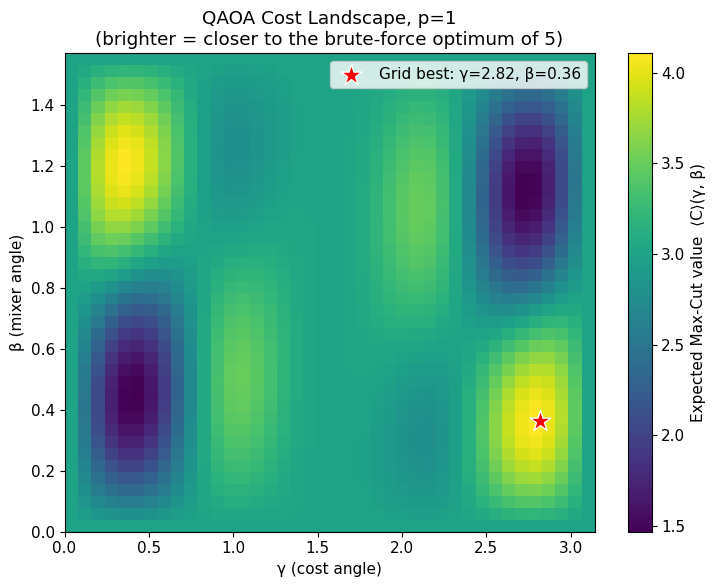

Best grid point found: γ=2.819, β=0.362, ⟨C⟩=4.109


In [8]:
def expected_cost_exact(gammas, betas, edge_list=edges):
    '''Exact (statevector-based) expected Max-Cut cost -- no sampling noise.'''
    qc = qaoa_circuit(n_nodes, gammas, betas, edge_list, measure=False)
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities_dict()
    total = 0.0
    for bitstring, p in probs.items():
        total += p * maxcut_cost(bitstring[::-1], edge_list)
    return total


gamma_grid = np.linspace(0, np.pi, 40)
beta_grid = np.linspace(0, np.pi / 2, 40)
landscape = np.zeros((len(beta_grid), len(gamma_grid)))

for bi, b in enumerate(beta_grid):
    for gi, g in enumerate(gamma_grid):
        landscape[bi, gi] = expected_cost_exact([g], [b])

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(landscape, origin='lower', aspect='auto', cmap='viridis',
               extent=[gamma_grid[0], gamma_grid[-1], beta_grid[0], beta_grid[-1]])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Expected Max-Cut value  ⟨C⟩(γ, β)")
ax.set_xlabel("γ (cost angle)")
ax.set_ylabel("β (mixer angle)")
ax.set_title("QAOA Cost Landscape, p=1\n(brighter = closer to the brute-force optimum "
              f"of {best_cost})")

best_idx = np.unravel_index(np.argmax(landscape), landscape.shape)
best_g, best_b = gamma_grid[best_idx[1]], beta_grid[best_idx[0]]
ax.scatter([best_g], [best_b], color='red', marker='*', s=250,
           edgecolor='white', linewidth=1, label=f'Grid best: γ={best_g:.2f}, β={best_b:.2f}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Best grid point found: γ={best_g:.3f}, β={best_b:.3f}, "
      f"⟨C⟩={landscape[best_idx]:.3f}")


**Teaching point:** notice the landscape is smooth but has multiple local maxima — this
is exactly why classical optimizers can get stuck, and why techniques like multiple random
restarts or good initial-parameter heuristics matter in practice.

<a id="10"></a>
## 10. Classical Parameter Optimization

Now let's use a real classical optimizer (`scipy.optimize.minimize`, method
**COBYLA** — a gradient-free method well suited to noisy, non-smooth quantum cost landscapes)
to search for good $(\gamma, \beta)$, instead of a brute-force grid.

We minimize $-\langle C \rangle$ (since `minimize` minimizes by default, and we want to
*maximize* the cut value).


Optimizer converged to: γ=-0.325, β=1.925
Expected cut value at optimum: 4.110 (brute-force optimum = 5)


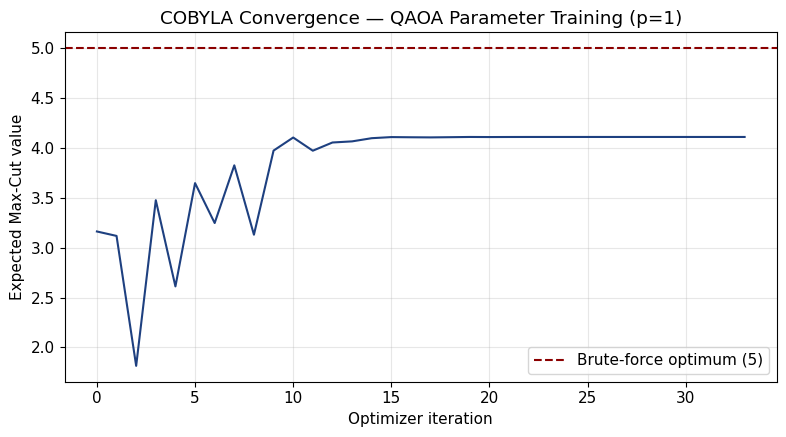

In [9]:
cost_history = []

def negative_expected_cost_p1(params):
    gamma, beta = params
    val = expected_cost_exact([gamma], [beta])
    cost_history.append(val)
    return -val


np.random.seed(7)
init_params = np.random.uniform(0, np.pi, size=2)

opt_result = minimize(
    negative_expected_cost_p1,
    init_params,
    method='COBYLA',
    options={'maxiter': 150, 'tol': 1e-4}
)

opt_gamma, opt_beta = opt_result.x
print(f"Optimizer converged to: γ={opt_gamma:.3f}, β={opt_beta:.3f}")
print(f"Expected cut value at optimum: {-opt_result.fun:.3f} "
      f"(brute-force optimum = {best_cost})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cost_history, color=NAVY, lw=1.5)
ax.axhline(y=best_cost, color=RED, linestyle='--', label=f'Brute-force optimum ({best_cost})')
ax.set_xlabel("Optimizer iteration")
ax.set_ylabel("Expected Max-Cut value")
ax.set_title("COBYLA Convergence — QAOA Parameter Training (p=1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<a id="11"></a>
## 11. Sampling the Optimized Circuit

With trained parameters in hand, let's actually **run** the circuit (with real shot-based
measurement, like on real hardware) and look at the distribution of bitstrings we get.


Bitstring   Frequency   Cut value 
01001       909         5         
10110       863         5         
10100       851         5         
01011       850         5         
00101       552         4         
11010       534         4         
01010       414         4         
10010       410         4         


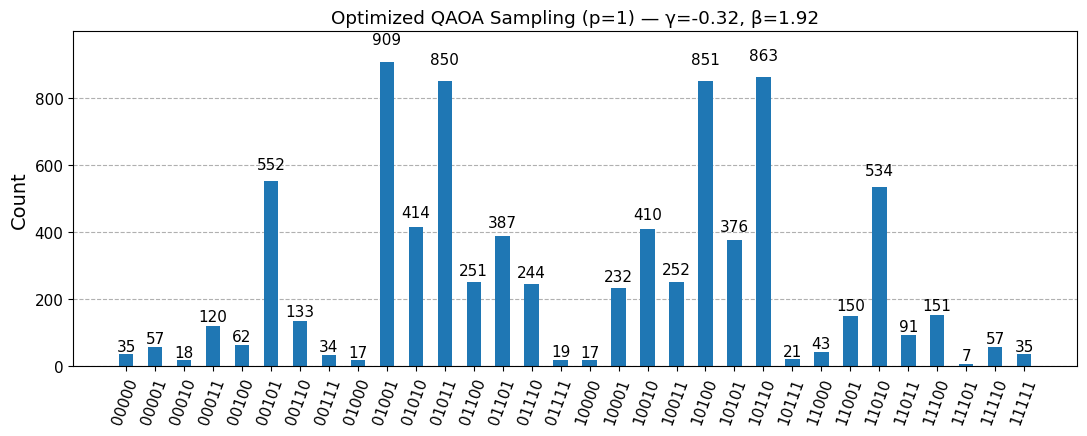

In [10]:
final_qc = qaoa_circuit(n_nodes, [opt_gamma], [opt_beta])
compiled_final = transpile(final_qc, simulator)
result_final = simulator.run(compiled_final, shots=8192).result()
counts_final = result_final.get_counts()

# Sort and show the top bitstrings by frequency, with their Max-Cut cost annotated
sorted_counts = sorted(counts_final.items(), key=lambda kv: kv[1], reverse=True)
print(f"{'Bitstring':<12}{'Frequency':<12}{'Cut value':<10}")
for bstr, freq in sorted_counts[:8]:
    print(f"{bstr:<12}{freq:<12}{maxcut_cost(bstr[::-1]):<10}")

fig = plot_histogram(counts_final, figsize=(11, 4.5),
                      title=f"Optimized QAOA Sampling (p=1) — γ={opt_gamma:.2f}, β={opt_beta:.2f}")
fig


Optimal-cut bitstrings sampled: 3473/8192 shots (42.4%)


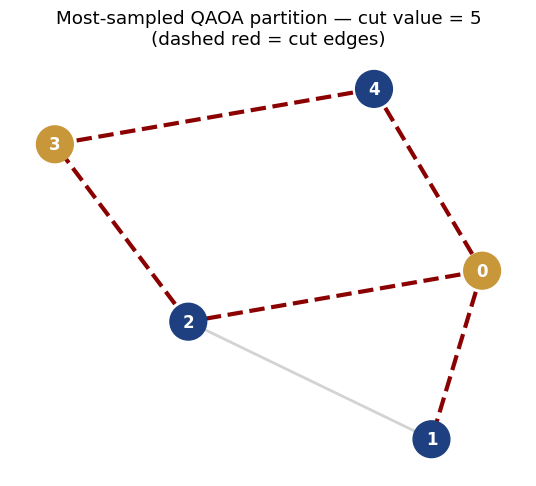

In [11]:
# Highlight which sampled bitstrings actually achieve the brute-force optimum
best_partition_hits = sum(freq for bstr, freq in counts_final.items()
                           if maxcut_cost(bstr[::-1]) == best_cost)
print(f"Optimal-cut bitstrings sampled: {best_partition_hits}/{sum(counts_final.values())} shots "
      f"({100*best_partition_hits/sum(counts_final.values()):.1f}%)")

# Visualize the best sampled partition on the graph
best_sampled = max(counts_final, key=counts_final.get)[::-1]
colors = [NAVY if bit == '0' else GOLD for bit in best_sampled]

fig, ax = plt.subplots(figsize=(5.5, 5))
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold', ax=ax)
cut_edges = [(i, j) for i, j in edges if best_sampled[i] != best_sampled[j]]
uncut_edges = [(i, j) for i, j in edges if best_sampled[i] == best_sampled[j]]
nx.draw_networkx_edges(G, pos, edgelist=uncut_edges, width=2, edge_color='lightgray', ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cut_edges, width=3, edge_color=RED, style='dashed', ax=ax)
ax.set_title(f"Most-sampled QAOA partition — cut value = {maxcut_cost(best_sampled)}\n"
             "(dashed red = cut edges)")
ax.axis('off')
plt.tight_layout()
plt.show()


<a id="12"></a>
## 12. Going Deeper: Increasing $p$

QAOA's approximation quality generally **improves as circuit depth $p$ increases** (more layers
= closer approximation to the ideal adiabatic path), at the cost of a longer circuit (more gates,
more noise on real hardware, and a larger classical parameter-search space: $2p$ parameters
instead of 2).

Let's build and train QAOA for $p = 1, 2, 3$ and compare.


In [12]:
def train_qaoa(p, n_restarts=3, maxiter=200, seed=0):
    '''Train a depth-p QAOA using multiple random restarts (to avoid bad local optima).'''
    rng = np.random.default_rng(seed)
    best_val = -np.inf
    best_params = None

    def negative_cost(params):
        gammas = params[:p]
        betas = params[p:]
        return -expected_cost_exact(list(gammas), list(betas))

    for r in range(n_restarts):
        init = rng.uniform(0, np.pi, size=2 * p)
        res = minimize(negative_cost, init, method='COBYLA',
                        options={'maxiter': maxiter, 'tol': 1e-4})
        if -res.fun > best_val:
            best_val = -res.fun
            best_params = res.x

    return best_val, best_params


results_by_p = {}
for p in [1, 2, 3]:
    val, params = train_qaoa(p, n_restarts=3, seed=p)
    results_by_p[p] = (val, params)
    print(f"p={p}:  best expected cut = {val:.3f}   "
          f"(approximation ratio = {val/best_cost:.3f})")


p=1:  best expected cut = 4.110   (approximation ratio = 0.822)


p=2:  best expected cut = 4.623   (approximation ratio = 0.925)


p=3:  best expected cut = 4.667   (approximation ratio = 0.933)


<a id="13"></a>
## 13. Approximation Ratio vs. Depth

The **approximation ratio** $r = \langle C \rangle_{\text{QAOA}} / C_{\text{optimal}}$ is the
standard way to measure QAOA solution quality (1.0 = perfect). Let's plot how it improves with
depth $p$ for our graph.


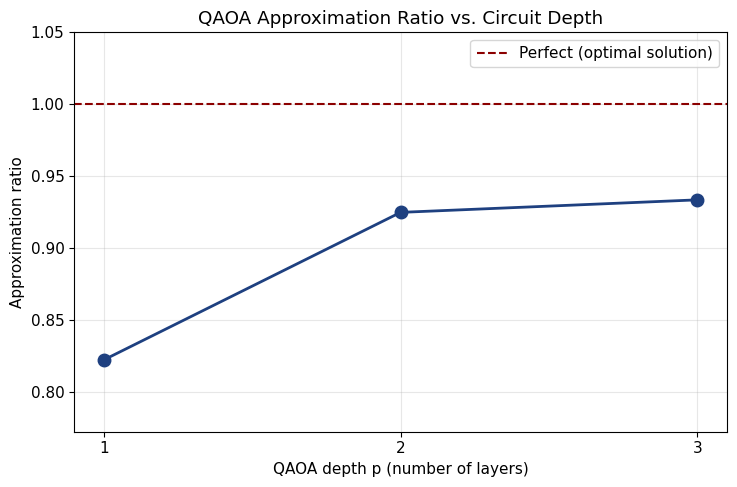

p=1: gammas=[0.325], betas=[2.788], ratio=0.822
p=2: gammas=[2.849 2.627], betas=[0.517 0.309], ratio=0.925
p=3: gammas=[0.281 0.439 2.611], betas=[2.542 1.328 1.729], ratio=0.933


In [13]:
ps = list(results_by_p.keys())
ratios = [results_by_p[p][0] / best_cost for p in ps]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ps, ratios, 'o-', color=NAVY, lw=2, markersize=9)
ax.axhline(y=1.0, color=RED, linestyle='--', label='Perfect (optimal solution)')
ax.set_xlabel("QAOA depth p (number of layers)")
ax.set_ylabel("Approximation ratio")
ax.set_xticks(ps)
ax.set_title("QAOA Approximation Ratio vs. Circuit Depth")
ax.set_ylim(min(ratios) - 0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for p in ps:
    val, params = results_by_p[p]
    gammas, betas = params[:p], params[p:]
    print(f"p={p}: gammas={np.round(gammas, 3)}, betas={np.round(betas, 3)}, "
          f"ratio={val/best_cost:.3f}")


**Discussion for students:** in the idealized, noiseless simulation above, even $p=1$ or
$p=2$ can already reach a good approximation ratio for small graphs. On **real hardware**, deeper
circuits accumulate more gate noise, so there's a practical trade-off between "theoretically
better with more layers" and "noisier in practice with more layers" — an active area of NISQ-era
research.

<a id="14"></a>
## 14. Beyond Max-Cut: QUBO for Other Problems

The same recipe — **(1)** write the problem as a QUBO, **(2)** map to an Ising cost Hamiltonian,
**(3)** build $U_C(\gamma)$ and $U_M(\beta)$, **(4)** train with a classical optimizer — extends
directly to other combinatorial problems:

| Problem | QUBO idea |
|---|---|
| **Knapsack** | Binary variable per item ($x_i{=}1$ if selected); penalty terms enforce the weight constraint, e.g. $H = -\sum_i v_i x_i + \lambda\left(\sum_i w_i x_i - W\right)^2$ |
| **TSP** | One binary variable per (city, time-step) pair; penalty terms enforce "each city visited exactly once" and "one city per time-step" constraints |
| **Graph Coloring** | One binary variable per (node, color) pair; penalty terms enforce "exactly one color per node" and "no adjacent same-color nodes" |
| **Portfolio Optimization** | Binary/integer variables for asset selection; QUBO balances expected return against risk (variance) terms |

**Key difference from Max-Cut:** these problems have **constraints**, which QUBO handles by
adding large penalty terms so that constraint-violating solutions have high cost and get
suppressed during optimization. Building the QAOA circuit itself is identical in structure —
only the Hamiltonian (and hence the RZZ/RZ gate angles) changes.

*(If you've already built QUBO formulations for Knapsack or TSP in a separate notebook, the
`cost_layer` / `mixer_layer` / `qaoa_circuit` functions above can be reused directly — just
supply the appropriate list of weighted $Z_iZ_j$ and $Z_i$ terms instead of the unweighted
Max-Cut edges.)*


<a id="15"></a>
## 15. Summary

| Concept | Key takeaway |
|---|---|
| **Problem class** | NP-hard combinatorial optimization (Max-Cut, Knapsack, TSP, ...) |
| **Encoding** | QUBO → Ising Hamiltonian $H_C = \sum h_i Z_i + \sum J_{ij} Z_i Z_j$ |
| **Cost unitary $U_C(\gamma)$** | $e^{-i\gamma H_C}$ → one RZZ (and RZ) gate per Hamiltonian term |
| **Mixer unitary $U_M(\beta)$** | $e^{-i\beta H_M}$ → RX rotation on every qubit |
| **QAOA circuit** | $p$ alternating rounds of $U_C, U_M$ applied to $|+\rangle^{\otimes n}$ |
| **Training** | Classical optimizer (COBYLA, gradient-based, etc.) tunes $(\gamma,\beta)$ to minimize $-\langle C\rangle$ |
| **Evaluation metric** | Approximation ratio $\langle C\rangle_{\text{QAOA}} / C_{\text{optimal}}$ |
| **Depth trade-off** | Higher $p$ → better theoretical approximation, but more gates → more real-hardware noise |

---

## Exercises for Students

1. **Change the graph.** Add or remove an edge from the Max-Cut graph in Section 4 and re-run
   the whole notebook. Does the optimal cut value and the best partition change as expected?
2. **Landscape exploration.** In Section 9, zoom the grid into a smaller $(\gamma,\beta)$ window
   around the best point found. Is there a finer-grained optimum nearby?
3. **Try a different classical optimizer.** Replace `method='COBYLA'` with `'Nelder-Mead'` or
   `'Powell'` in Section 10. Compare convergence speed and final cost.
4. **Multiple restarts matter.** Reduce `n_restarts` to 1 in Section 12 and see whether $p=2,3$
   sometimes perform *worse* than $p=1$ due to getting stuck in a bad local optimum.
5. **(Challenge) Larger graph.** Extend the graph to 8–10 nodes. What happens to brute-force
   runtime? What happens to the QAOA landscape/optimization difficulty?
6. **(Challenge) Weighted Max-Cut.** Modify `maxcut_cost` and `cost_layer` to support edge
   weights $w_{ij}$ (i.e. $H_C = \sum w_{ij}\frac{1-Z_iZ_j}{2}$). Confirm the optimal partition
   changes appropriately when some edges are weighted much higher than others.
7. **(Challenge) Knapsack QUBO.** Using the table in Section 14, formulate a 4-item Knapsack
   problem as a QUBO by hand, derive the corresponding Ising coefficients $h_i, J_{ij}$, and
   adapt the `cost_layer` function to include the necessary RZ (single-qubit) gates in addition
   to RZZ gates.
8. **(Challenge) Real hardware.** Run the optimized $p=1$ circuit from Section 10 on an IBM
   Quantum backend via `qiskit-ibm-runtime` and compare the sampled distribution to the
   noiseless simulation in Section 11. Discuss what changed and why.

---

*Notebook built for classroom use — feel free to adapt the graph, color scheme, optimizer choice,
and depth $p$ to fit your lecture.*
